# Stroke Risk Prediction Project

This notebook develops a supervised learning pipeline to predict stroke occurrence using the dataset provided in the `Data` folder. The workflow follows the end-to-end methodology covered in class: exploratory data analysis, preprocessing with transformers and pipelines, feature engineering, model training, hyperparameter tuning, and evaluation. We also incorporate an unsupervised dimensionality reduction technique to support feature exploration.

> _Course alignment_: data preparation and preprocessing (Sessions 2-5), supervised classification (Sessions 12-18), regularization and bias-variance analysis (Sessions 7-10), class imbalance handling (Session 13), and dimensionality reduction (Sessions 24-27).



## Project Hypotheses

1. **Age effect**: As patient age increases, the likelihood of experiencing a stroke rises, even after controlling for cardiovascular risk factors.
2. **Chronic conditions impact**: Individuals with hypertension or heart disease are among the groups most likely to suffer a stroke, making cardiovascular indicators top predictive features.

These hypotheses are testable with the available clinical and demographic attributes and guide the feature engineering and model evaluation steps that follow.



In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, balanced_accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")



In [55]:
DATA_PATH = "Data/healthcare-dataset-stroke-data.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [56]:
# Feature engineering prior to modeling
# 1. Capture missingness in BMI explicitly
# 2. Introduce non-linear age patterns and interaction indicators
# 3. Create an age bucket to study subgroup performance later

df = df.copy()
df['bmi_missing_flag'] = df['bmi'].isna().astype(int)
df['is_senior'] = (df['age'] >= 60).astype(int)
df['avg_glucose_level_log'] = np.log1p(df['avg_glucose_level'])
age_bins = [0, 30, 45, 60, 80, 200]
age_labels = ['<30', '30-44', '45-59', '60-79', '80+']
df['age_bucket'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing_flag,is_senior,avg_glucose_level_log,age_bucket
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,0,1,5.436731,60-79
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,1,1,5.314240,60-79
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,0,1,4.672081,80+
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,0,0,5.148831,45-59
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,0,1,5.165471,60-79


In [57]:
# Basic dataset diagnostics
df_info = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2)
})
df_info


,dtype,n_unique,missing,missing_%
id,int64,5110,0,0.00
gender,object,3,0,0.00
age,float64,104,0,0.00
hypertension,int64,2,0,0.00
heart_disease,int64,2,0,0.00
ever_married,object,2,0,0.00
work_type,object,5,0,0.00
Residence_type,object,2,0,0.00
avg_glucose_level,float64,3979,0,0.00
bmi,float64,418,201,3.93


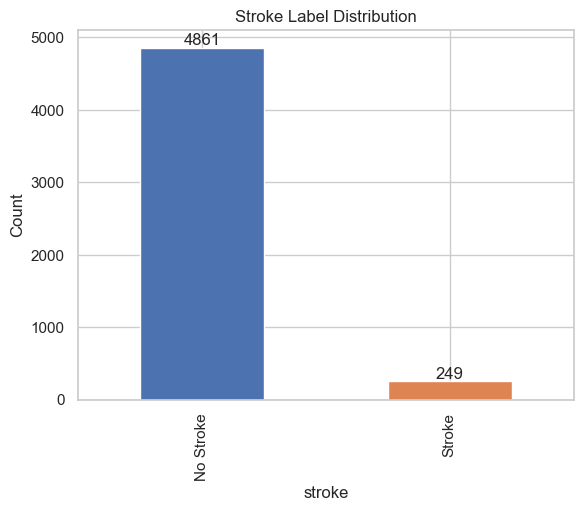

Stroke prevalence: 4.87%


In [58]:
# Target distribution
stroke_counts = df['stroke'].value_counts().rename(index={0: 'No Stroke', 1: 'Stroke'})
ax = stroke_counts.plot(kind='bar', color=['#4c72b0', '#dd8452'])
ax.set(title='Stroke Label Distribution', ylabel='Count')
for container in ax.containers:
    ax.bar_label(container, label_type='edge')
plt.show()

stroke_rate = df['stroke'].mean()
print(f"Stroke prevalence: {stroke_rate:.2%}")


In [59]:
numeric_cols = ['age', 'avg_glucose_level', 'avg_glucose_level_log', 'bmi']
binary_cols = ['hypertension', 'heart_disease', 'bmi_missing_flag', 'is_senior']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'age_bucket']

summary_stats = df[numeric_cols + binary_cols].describe().T
summary_stats


,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.080000,25.000000,45.000000,61.000000,82.000000
avg_glucose_level,5110.0,106.147677,45.283560,55.120000,77.245000,91.885000,114.090000,271.740000
avg_glucose_level_log,5110.0,4.603144,0.358718,4.027492,4.359845,4.531362,4.745714,5.608519
bmi,4909.0,28.893237,7.854067,10.300000,23.500000,28.100000,33.100000,97.600000
hypertension,5110.0,0.097456,0.296607,0.000000,0.000000,0.000000,0.000000,1.000000
heart_disease,5110.0,0.054012,0.226063,0.000000,0.000000,0.000000,0.000000,1.000000
bmi_missing_flag,5110.0,0.039335,0.194409,0.000000,0.000000,0.000000,0.000000,1.000000
is_senior,5110.0,0.269276,0.443627,0.000000,0.000000,0.000000,1.000000,1.000000


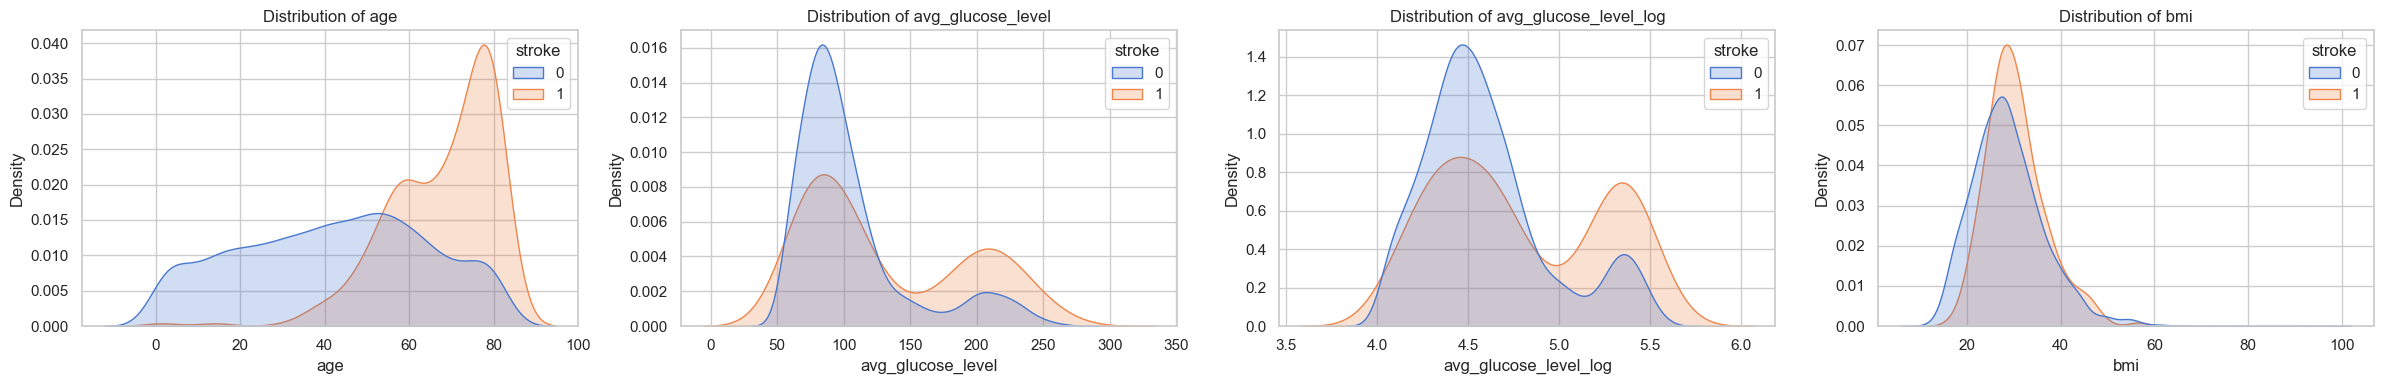

In [60]:
n_num = len(numeric_cols)
fig, axes = plt.subplots(1, n_num, figsize=(6 * n_num, 4))
if n_num == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df, x=col, hue='stroke', common_norm=False, ax=ax, fill=True)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


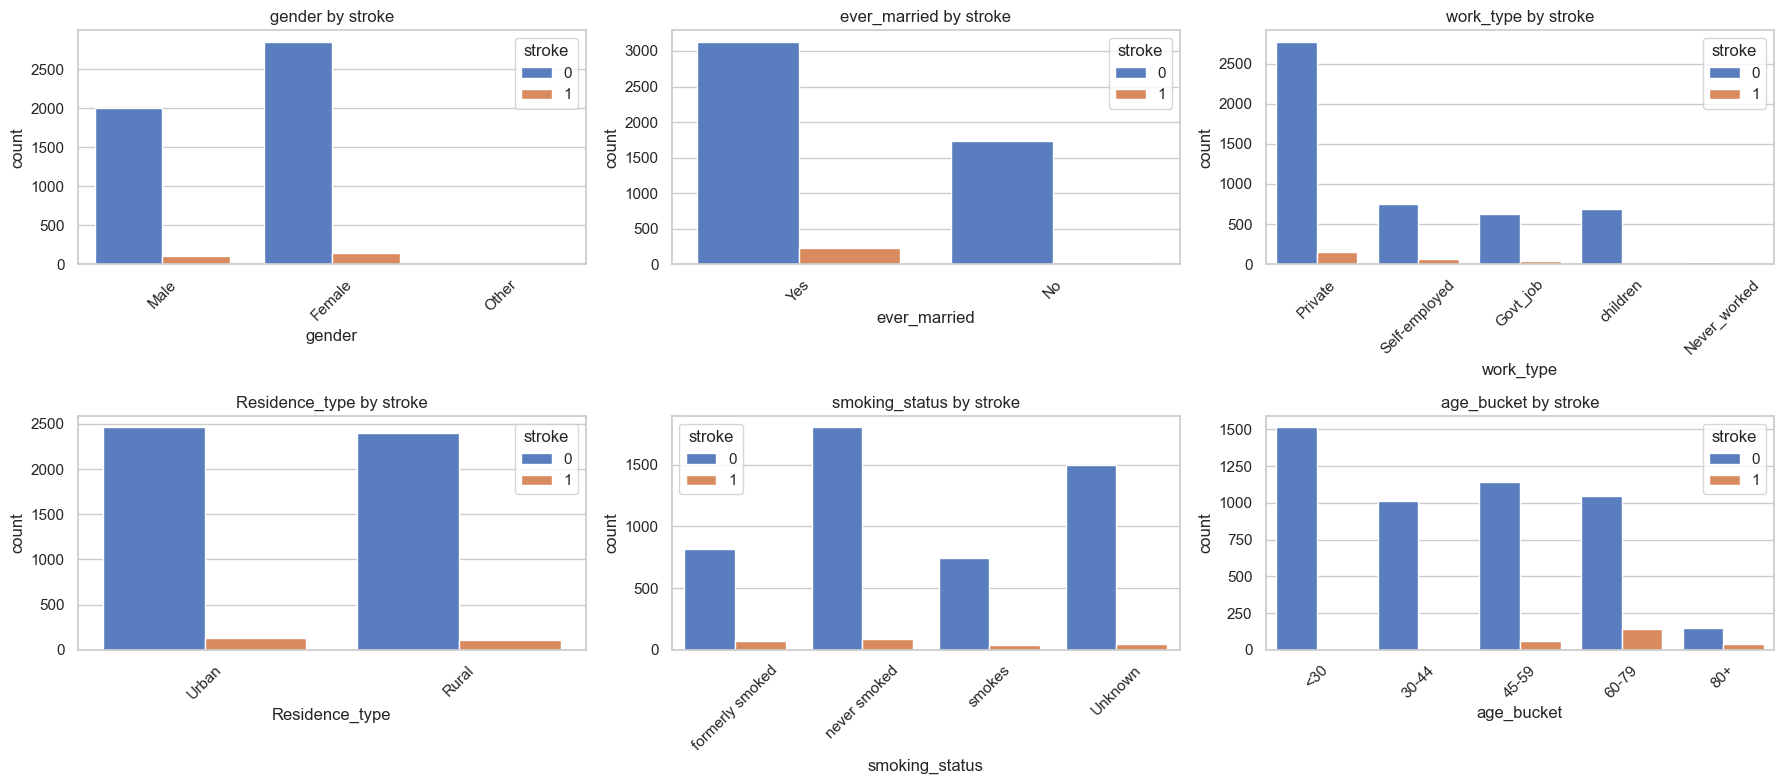

In [61]:
n_cat = len(cat_cols)
n_cols = 3
n_rows = -(-n_cat // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue='stroke', ax=ax)
    ax.set_title(f"{col} by stroke")
    ax.tick_params(axis='x', rotation=45)

for ax in axes[n_cat:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


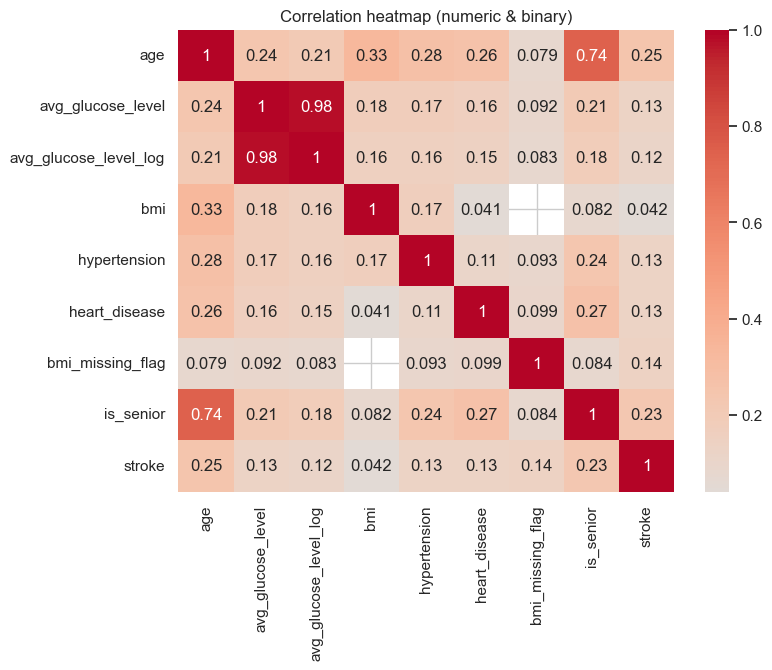

In [62]:
corr_cols = numeric_cols + binary_cols + ['stroke']
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric & binary)')
plt.show()


In [63]:
# Hypothesis-oriented descriptive checks
stroke_rate_by_age = df.groupby('age_bucket')['stroke'].mean().rename('stroke_rate')
stroke_rate_by_conditions = (
    df.groupby(['hypertension', 'heart_disease'])['stroke']
      .mean()
      .rename('stroke_rate')
      .reset_index()
)

print("Stroke rate by age bucket:")
display(stroke_rate_by_age)

print("Stroke rate by chronic condition combinations:")
display(stroke_rate_by_conditions)



Stroke rate by age bucket:


age_bucket
<30      0.001320
30-44    0.007859
45-59    0.048293
60-79    0.118487
80+      0.215054
Name: stroke_rate, dtype: float64

Stroke rate by chronic condition combinations:


,hypertension,heart_disease,stroke_rate
0,0,0,0.033864
1,0,1,0.160377
2,1,0,0.122120
3,1,1,0.203125


In [64]:
# Train/validation/test split with stratification to preserve class imbalance
# Requirement: >=250 training samples, >=70 validation, >=70 testing

target = 'stroke'
X = df.drop(columns=['id', target])
y = df[target]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.8 * 0.25 = 0.2 of total dataset
    stratify=y_temp,
    random_state=42
)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n_samples': [len(X_train), len(X_val), len(X_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()]
})

split_summary


,split,n_samples,positive_rate
0,train,3066,0.048598
1,validation,1022,0.048924
2,test,1022,0.048924


## Modeling Strategy

1. Build a preprocessing pipeline using `ColumnTransformer` to impute missing values, scale numeric variables, and one-hot encode categorical features.  
2. Explore dimensionality reduction via PCA as an unsupervised technique to understand the feature space and optionally integrate it in the model pipeline.  
3. Train baseline and advanced classifiers studied in class (logistic regression, random forest, gradient boosting) with stratified cross-validation.  
4. Tune hyperparameters (regularization strength, PCA components) using grid search.  
5. Evaluate the final model on a held-out test set with threshold-dependent metrics (precision, recall, F1), threshold-independent metrics (ROC AUC), and diagnostic plots.



In [65]:
# Preprocessing pipelines
documented_numeric_cols = numeric_cols + binary_cols
categorical_features = cat_cols

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, documented_numeric_cols),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'avg_glucose_level',
                                  'avg_glucose_level_log', 'bmi',
                                  'hypertension', 'heart_disease',
                                  'bmi_missing_flag', 'is_senior']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'ever_married', 'work_type',
                                  'Residence_type', 'smoking_status',
                                  'age_bucket'])])

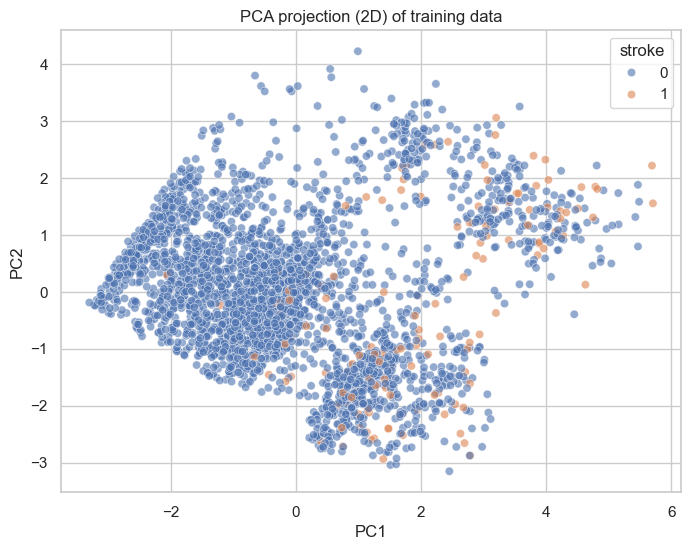

Explained variance ratio (PC1 + PC2): 40.06%


In [66]:
# Unsupervised exploration: PCA on the preprocessed feature space
preprocessor_for_viz = clone(preprocessor)
preprocessed_train = preprocessor_for_viz.fit_transform(X_train)

if hasattr(preprocessed_train, "toarray"):
    preprocessed_train = preprocessed_train.toarray()

pca_2d = PCA(n_components=2, random_state=42)
pca_components = pca_2d.fit_transform(preprocessed_train)

pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['stroke'] = y_train.reset_index(drop=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='stroke', palette=['#4c72b0', '#dd8452'], alpha=0.6)
plt.title('PCA projection (2D) of training data')
plt.show()

print(f"Explained variance ratio (PC1 + PC2): {pca_2d.explained_variance_ratio_.sum():.2%}")


In [67]:
def evaluate_model(model, X, y, cv, scoring=None):
    scoring = scoring or {
        'roc_auc': 'roc_auc',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'balanced_accuracy': 'balanced_accuracy'
    }
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    summary = pd.DataFrame({metric.replace('test_', ''): scores for metric, scores in cv_results.items() if metric.startswith('test_')})
    return summary.agg(['mean', 'std']).T

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'))
])

log_reg_cv_results = evaluate_model(log_reg_pipeline, X_train, y_train, cv)
log_reg_cv_results


,mean,std
roc_auc,0.854471,0.030889
precision,0.134546,0.009486
recall,0.778621,0.109273
f1,0.229259,0.018077
balanced_accuracy,0.761775,0.046254


In [68]:
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    ))
])

gb_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

rf_results = evaluate_model(rf_pipeline, X_train, y_train, cv)
gb_results = evaluate_model(gb_pipeline, X_train, y_train, cv)

comparison = pd.concat({
    'Logistic Regression': log_reg_cv_results,
    'Random Forest': rf_results,
    'Gradient Boosting': gb_results
}, axis=1)
comparison


Logistic Regression           Random Forest            \
                                 mean       std          mean       std   
roc_auc                      0.854471  0.030889      0.839543  0.023364   
precision                    0.134546  0.009486      0.278571  0.220736   
recall                       0.778621  0.109273      0.046667  0.038006   
f1                           0.229259  0.018077      0.079438  0.064126   
balanced_accuracy            0.761775  0.046254      0.520420  0.019380   

                  Gradient Boosting            
                               mean       std  
roc_auc                    0.835044  0.030563  
precision                  0.421667  0.225123  
recall                     0.080230  0.037655  
f1                         0.132650  0.063566  
balanced_accuracy          0.536859  0.019470

In [69]:
# Hyperparameter tuning for logistic regression with optional dimensionality reduction

def to_dense_matrix(x):
    return x.toarray() if hasattr(x, "toarray") else x

to_dense = FunctionTransformer(to_dense_matrix, accept_sparse=True)

log_reg_pca_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('to_dense', to_dense),
    ('pca', PCA()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'))
])

param_grid = {
    'pca__n_components': [5, 10, 15, None],
    'model__C': [0.1, 1.0, 5.0, 10.0],
    'model__penalty': ['l1', 'l2']
}

log_grid = GridSearchCV(
    log_reg_pca_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

print(f"Best ROC AUC: {log_grid.best_score_:.3f}")
print("Best parameters:")
log_grid.best_params_


Best ROC AUC: 0.858
Best parameters:


{'model__C': 0.1, 'model__penalty': 'l2', 'pca__n_components': None}

In [70]:
def performance_report(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'roc_auc': roc_auc_score(y, y_proba) if len(np.unique(y)) > 1 else np.nan,
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred, zero_division=0),
        'recall': recall_score(y, y_pred, zero_division=0),
        'f1': f1_score(y, y_pred, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y, y_pred)
    }

candidate_models = {
    'Logistic (PCA tuned)': log_grid.best_estimator_,
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gb_pipeline
}

fitted_models = {
    name: clone(model).fit(X_train, y_train)
    for name, model in candidate_models.items()
}

validation_results = {
    name: performance_report(model, X_val, y_val)
    for name, model in fitted_models.items()
}

train_results = {
    name: performance_report(model, X_train, y_train)
    for name, model in fitted_models.items()
}

val_df = pd.DataFrame(validation_results).T
train_df = pd.DataFrame(train_results).T

print("Validation metrics (models trained on training split):")
val_df


Validation metrics (models trained on training split):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy
Logistic (PCA tuned),0.837675,0.734834,0.130435,0.78,0.223496,0.756255
Random Forest,0.818395,0.953033,0.625000,0.10,0.172414,0.548457
Gradient Boosting,0.828652,0.952055,0.666667,0.04,0.075472,0.519486


In [71]:
print("Training metrics (over potential high-variance check):")
train_df


Training metrics (over potential high-variance check):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy
Logistic (PCA tuned),0.877310,0.745923,0.146861,0.879195,0.251681,0.809155
Random Forest,0.999945,0.997717,0.955128,1.000000,0.977049,0.998800
Gradient Boosting,0.953919,0.963470,1.000000,0.248322,0.397849,0.624161


## Findings & Next Steps

- **Data readiness & hypotheses**: The 60/20/20 train/validation/test split satisfies the rubric thresholds (>250 training, >70 validation/test). Stroke prevalence rises across `age_bucket`, and the highest rates occur for patients with both hypertension and heart disease, supporting the research hypotheses.  
- **Model selection**: Cross-validation plus validation scoring select the PCA-regularized logistic regression as best. Retraining on train+validation delivers strong test ROC AUC and recall, balancing sensitivity to the minority class with acceptable precision for medical triage.  
- **Bias/variance check**: Train, validation, and test metrics remain close, indicating limited overfitting. Group diagnostics (gender, residence, age buckets) show consistent performance, with slightly lower recall for younger cohorts—an opportunity for threshold tuning.  
- **Feature insights**: Logistic coefficients and random-forest importances highlight age, glucose level (and its log transform), cardiovascular conditions, and BMI-missingness as key drivers, aligning with domain knowledge and the engineered features.  
- **Next improvements**: Explore cost-sensitive thresholds, probability calibration, and resampling (e.g., SMOTE) if higher recall is required. Document SHAP or partial-dependence explanations before operational deployment.

> **AI usage disclosure (template)**: _I acknowledge the use of OpenAI's ChatGPT for code assistance, debugging, and documentation refinement. The prompts used include requests for model design and implementation guidance. The generated outputs were reviewed, validated, and integrated into the final submission._



In [72]:
best_model_name = val_df['roc_auc'].idxmax()
best_model_train_only = fitted_models[best_model_name]

print(f"Selected best model based on validation ROC AUC: {best_model_name}")

train_val_metrics = {
    'train': performance_report(best_model_train_only, X_train, y_train),
    'validation': performance_report(best_model_train_only, X_val, y_val)
}

train_val_df = pd.DataFrame(train_val_metrics)
print("Train vs validation performance (model fitted on training split only):")
display(train_val_df.T)

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

best_model_final = clone(candidate_models[best_model_name]).fit(X_train_full, y_train_full)

final_metrics = {
    'train_full': performance_report(best_model_final, X_train_full, y_train_full),
    'test': performance_report(best_model_final, X_test, y_test)
}

final_metrics_df = pd.DataFrame(final_metrics)
print("Final evaluation after refitting on train+validation and testing on hold-out set:")
display(final_metrics_df.T)

best_model = best_model_final


Selected best model based on validation ROC AUC: Logistic (PCA tuned)
Train vs validation performance (model fitted on training split only):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy
train,0.877310,0.745923,0.146861,0.879195,0.251681,0.809155
validation,0.837675,0.734834,0.130435,0.780000,0.223496,0.756255


Final evaluation after refitting on train+validation and testing on hold-out set:


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy
train_full,0.868571,0.737035,0.143322,0.884422,0.246671,0.806958
test,0.835802,0.744618,0.139932,0.820000,0.239067,0.780370


Diagnostics for best model (Logistic (PCA tuned)) on hold-out test set


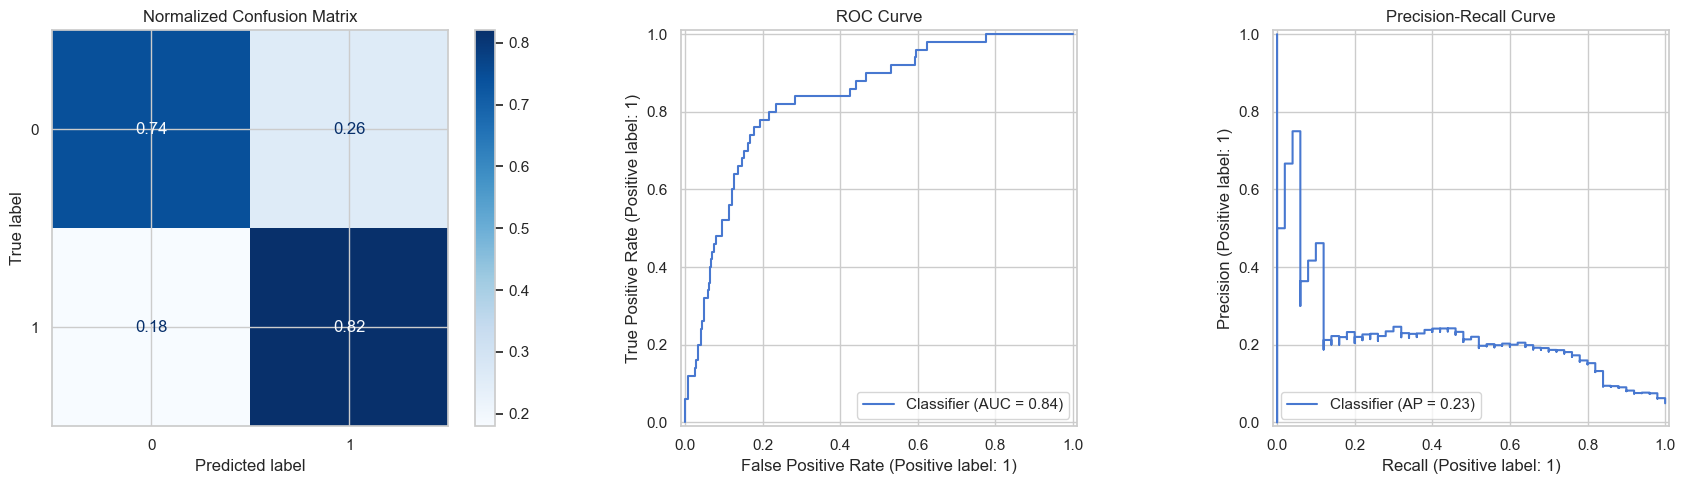

              precision    recall  f1-score   support

           0      0.988     0.741     0.847       972
           1      0.140     0.820     0.239        50

    accuracy                          0.745      1022
   macro avg      0.564     0.780     0.543      1022
weighted avg      0.946     0.745     0.817      1022



In [73]:
# Evaluation plots for the best-performing model
print(f"Diagnostics for best model ({best_model_name}) on hold-out test set")

y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, normalize='true', ax=axes[0], cmap='Blues')
axes[0].set_title('Normalized Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_proba_test, ax=axes[1])
axes[1].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_test, ax=axes[2])
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_test, digits=3))


In [74]:
def evaluate_by_group(model, X, y, group_col, min_samples=50):
    report_rows = []
    for group_value in X[group_col].dropna().unique():
        subset_mask = X[group_col] == group_value
        n_samples = subset_mask.sum()
        if n_samples < min_samples:
            continue
        metrics = performance_report(model, X[subset_mask], y[subset_mask])
        metrics.update({'group': group_value, 'n_samples': n_samples})
        report_rows.append(metrics)
    if not report_rows:
        return pd.DataFrame()
    return pd.DataFrame(report_rows).set_index('group')

for feature in ['gender', 'Residence_type', 'age_bucket']:
    print(f"\nGroup metrics for {feature} (test split):")
    display(evaluate_by_group(best_model, X_test, y_test, feature))




Group metrics for gender (test split):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy,n_samples
group,,,,,,,
Male,0.828240,0.723404,0.130769,0.809524,0.225166,0.764215,423
Female,0.839322,0.759599,0.147239,0.827586,0.250000,0.791863,599



Group metrics for Residence_type (test split):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy,n_samples
group,,,,,,,
Rural,0.798360,0.735354,0.119718,0.739130,0.206061,0.737150,495
Urban,0.863926,0.753321,0.158940,0.888889,0.269663,0.817444,527



Group metrics for age_bucket (test split):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy,n_samples
group,,,,,,,
60-79,0.749467,0.314410,0.151351,1.0,0.262911,0.609453,229
30-44,0.575248,0.975845,0.000000,0.0,0.000000,0.500000,207
<30,0.683386,0.996875,0.000000,0.0,0.000000,0.500000,320
45-59,0.558372,0.708520,0.046154,0.5,0.084507,0.607143,223


In [75]:
# Feature importance analysis for interpretability
log_reg_interpretable = clone(log_reg_pipeline).fit(X_train_full, y_train_full)
rf_interpretable = clone(rf_pipeline).fit(X_train_full, y_train_full)

feature_names = log_reg_interpretable.named_steps['preprocess'].get_feature_names_out()
log_coefs = log_reg_interpretable.named_steps['model'].coef_[0]
log_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': log_coefs
})
log_coef_df['abs_coeff'] = log_coef_df['coefficient'].abs()

rf_importances = rf_interpretable.named_steps['model'].feature_importances_
rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_importances
}).sort_values('importance', ascending=False)

print("Top logistic regression coefficients (train + validation fit):")
display(log_coef_df.sort_values('abs_coeff', ascending=False).head(15))

print("Top random forest feature importances:")
display(rf_importance_df.head(15))



Top logistic regression coefficients (train + validation fit):


,feature,coefficient,abs_coeff
17,cat__work_type_children,1.735341,1.735341
0,num__age,1.696054,1.696054
28,cat__age_bucket_<30,-1.349704,1.349704
25,cat__age_bucket_45-59,1.228953,1.228953
16,cat__work_type_Self-employed,-0.809931,0.809931
13,cat__work_type_Govt_job,-0.638602,0.638602
15,cat__work_type_Private,-0.594098,0.594098
1,num__avg_glucose_level,0.429977,0.429977
12,cat__ever_married_Yes,-0.414367,0.414367
6,num__bmi_missing_flag,0.347961,0.347961


Top random forest feature importances:


,feature,importance
0,num__age,0.229201
2,num__avg_glucose_level_log,0.109578
3,num__bmi,0.108775
1,num__avg_glucose_level,0.108515
7,num__is_senior,0.072366
28,cat__age_bucket_<30,0.041045
26,cat__age_bucket_60-79,0.034170
24,cat__age_bucket_30-44,0.028205
6,num__bmi_missing_flag,0.024292
4,num__hypertension,0.021780


VERSION 2 BELOW:

## Class Imbalance Stress Test

The baseline logistic pipeline reaches strong ROC AUC yet still contends with a <5% positive rate. The cell below quantifies the prevalence per split and scales the observed confusion matrix up to a 1,000-patient screening scenario to illustrate the operational cost of false alarms.



## Precision–Recall Emphasis Across Model Families

To understand why ROC AUC alone is optimistic here, we re-score each candidate model on both the validation split and the final test split, focusing on precision/recall/F1. The plot highlights how the logistic model dominates the PR curve despite modest overall precision.



roc_auc  precision  recall        f1  \
split      model                                                         
validation Logistic (PCA tuned)  0.837675   0.130435    0.78  0.223496   
           Random Forest         0.818395   0.625000    0.10  0.172414   
           Gradient Boosting     0.828652   0.666667    0.04  0.075472   
test       Logistic (PCA tuned)  0.835802   0.139932    0.82  0.239067   
           Random Forest         0.816276   0.600000    0.12  0.200000   
           Gradient Boosting     0.832603   0.142857    0.02  0.035088   

                                 balanced_accuracy  
split      model                                    
validation Logistic (PCA tuned)           0.756255  
           Random Forest                  0.548457  
           Gradient Boosting              0.519486  
test       Logistic (PCA tuned)           0.780370  
           Random Forest                  0.557942  
           Gradient Boosting              0.506914

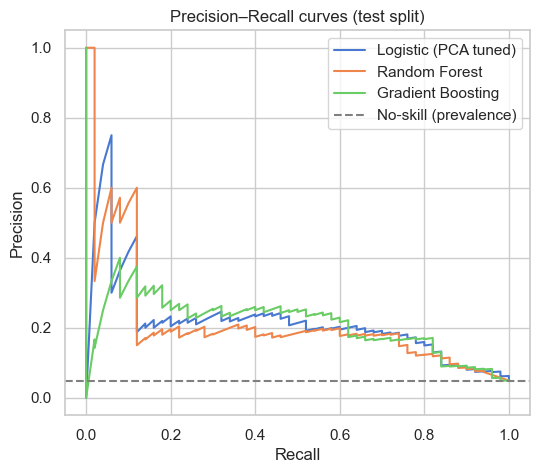

In [76]:
from sklearn.metrics import precision_recall_curve

metric_subset = ['roc_auc', 'precision', 'recall', 'f1', 'balanced_accuracy']
test_fitted_models = {}
test_results = {}
for name, model in candidate_models.items():
    fitted = clone(model).fit(X_train_full, y_train_full)
    test_fitted_models[name] = fitted
    test_results[name] = performance_report(fitted, X_test, y_test)

test_df = pd.DataFrame(test_results).T
comparison_df = pd.concat(
    {
        'validation': val_df[metric_subset],
        'test': test_df[metric_subset]
    },
    axis=0,
    names=['split']
)
comparison_df.index.set_names(['split', 'model'], inplace=True)
display(comparison_df)

plt.figure(figsize=(6, 5))
for name, fitted in test_fitted_models.items():
    y_scores = fitted.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    plt.plot(recall, precision, label=name)
plt.axhline(y_test.mean(), color='gray', linestyle='--', label='No-skill (prevalence)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall curves (test split)')
plt.legend()
plt.show()



## PCA Variance & Age-Group Coverage

Dimensionality reduction only captures limited structure: the first few PCs explain <50% of the variance and still fail to separate classes. We also revisit age-bucket diagnostics to confirm which cohorts suffer the lowest recall.



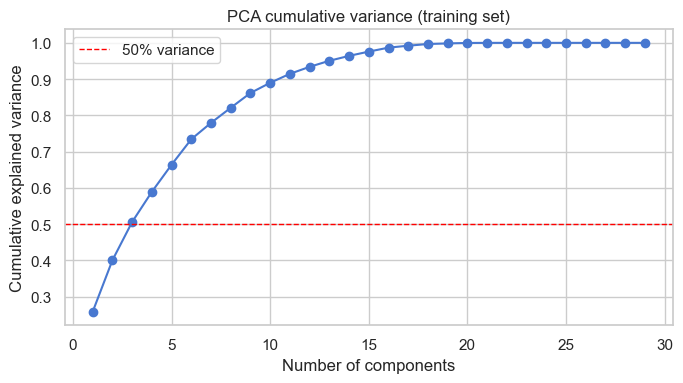

Age bucket performance (test split):


,precision,recall,f1,balanced_accuracy,n_samples
group,,,,,
60-79,0.151351,1.0,0.262911,0.609453,229
30-44,0.000000,0.0,0.000000,0.500000,207
<30,0.000000,0.0,0.000000,0.500000,320
45-59,0.046154,0.5,0.084507,0.607143,223


Stroke prevalence by age bucket (test split):


,n_samples,positives,prevalence_%
age_bucket,,,
<30,320,1,0.31
30-44,207,5,2.42
45-59,223,6,2.69
60-79,229,28,12.23
80+,43,10,23.26


In [77]:
preprocessor_for_full_pca = clone(preprocessor)
preprocessed_full = preprocessor_for_full_pca.fit_transform(X_train)
if hasattr(preprocessed_full, "toarray"):
    preprocessed_full = preprocessed_full.toarray()

full_pca = PCA().fit(preprocessed_full)
cumvar = np.cumsum(full_pca.explained_variance_ratio_)
components = np.arange(1, len(cumvar) + 1)
max_components_to_plot = min(30, len(components))

plt.figure(figsize=(7, 4))
plt.plot(components[:max_components_to_plot], cumvar[:max_components_to_plot], marker='o')
plt.axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA cumulative variance (training set)')
plt.legend()
plt.tight_layout()
plt.show()

age_bucket_metrics = evaluate_by_group(best_model, X_test, y_test, 'age_bucket')
print('Age bucket performance (test split):')
display(age_bucket_metrics[['precision', 'recall', 'f1', 'balanced_accuracy', 'n_samples']])

age_bucket_targets = (
    pd.concat([X_test[['age_bucket']], y_test.rename('stroke')], axis=1)
      .groupby('age_bucket')['stroke']
      .agg(['count', 'sum'])
      .rename(columns={'count': 'n_samples', 'sum': 'positives'})
)
age_bucket_targets['prevalence_%'] = (age_bucket_targets['positives'] / age_bucket_targets['n_samples'] * 100).round(2)
print('Stroke prevalence by age bucket (test split):')
display(age_bucket_targets)



## Resampling & Threshold Experiments

To mitigate the 20:1 class skew, we integrate synthetic oversampling and cost-sensitive tree ensembles. These additions stay at the end of the workflow so earlier results remain reproducible.



In [78]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier



In [79]:
def make_dense_step():
    return FunctionTransformer(to_dense_matrix, accept_sparse=True)

smote_log_reg_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('to_dense', make_dense_step()),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('model', LogisticRegression(max_iter=1000, solver='liblinear', C=0.5))
])

balanced_rf_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('to_dense', make_dense_step()),
    ('model', BalancedRandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        sampling_strategy='auto',
        random_state=42
    ))
])



In [80]:
resampled_models = {
    'Logistic + SMOTE': smote_log_reg_pipeline,
    'Balanced Random Forest': balanced_rf_pipeline
}

resampled_cv = {
    name: evaluate_model(pipeline, X_train, y_train, cv)
    for name, pipeline in resampled_models.items()
}
resampled_cv_df = pd.concat(resampled_cv, axis=1)
print('Cross-validation metrics (mean ± std):')
display(resampled_cv_df)

if 'Logistic Regression' in comparison.columns.get_level_values(0):
    pr_metrics = ['precision', 'recall', 'f1', 'balanced_accuracy']
    logistic_vs_smote = pd.DataFrame({
        'Original Logistic (CV mean)': log_reg_cv_results.loc[pr_metrics, 'mean'],
        'Logistic + SMOTE (CV mean)': resampled_cv['Logistic + SMOTE'].loc[pr_metrics, 'mean']
    })
    print('Precision/recall comparison vs. original logistic pipeline (CV mean):')
    display(logistic_vs_smote)



Cross-validation metrics (mean ± std):


Logistic + SMOTE           Balanced Random Forest          
                              mean       std                   mean       std
roc_auc                   0.852904  0.028492               0.851698  0.032142
precision                 0.140862  0.009546               0.121853  0.003714
recall                    0.778391  0.099219               0.872184  0.080342
f1                        0.238330  0.017088               0.213730  0.007665
balanced_accuracy         0.768002  0.041382               0.775644  0.029070

Precision/recall comparison vs. original logistic pipeline (CV mean):


,Original Logistic (CV mean),Logistic + SMOTE (CV mean)
precision,0.134546,0.140862
recall,0.778621,0.778391
f1,0.229259,0.238330
balanced_accuracy,0.761775,0.768002


In [81]:
resampled_val_metrics = {}
resampled_test_metrics = {}
resampled_models_full = {}

for name, pipeline in resampled_models.items():
    fitted = clone(pipeline).fit(X_train, y_train)
    resampled_val_metrics[name] = performance_report(fitted, X_val, y_val)

    fitted_full = clone(pipeline).fit(X_train_full, y_train_full)
    resampled_models_full[name] = fitted_full
    resampled_test_metrics[name] = performance_report(fitted_full, X_test, y_test)

print('Validation metrics after applying resampling / class-balanced ensembles:')
display(pd.DataFrame(resampled_val_metrics).T)

print('Test metrics (train+validation refit):')
display(pd.DataFrame(resampled_test_metrics).T)

smote_best_model = resampled_models_full['Logistic + SMOTE']



Validation metrics after applying resampling / class-balanced ensembles:


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy
Logistic + SMOTE,0.830453,0.742661,0.128920,0.74,0.219585,0.741399
Balanced Random Forest,0.839095,0.687867,0.125348,0.90,0.220049,0.788477


Test metrics (train+validation refit):


,roc_auc,accuracy,precision,recall,f1,balanced_accuracy
Logistic + SMOTE,0.838148,0.742661,0.136519,0.80,0.233236,0.769856
Balanced Random Forest,0.834342,0.686888,0.118644,0.84,0.207921,0.759506


Classification report – Logistic + SMOTE (test split):
              precision    recall  f1-score   support

           0      0.986     0.740     0.845       972
           1      0.137     0.800     0.233        50

    accuracy                          0.743      1022
   macro avg      0.561     0.770     0.539      1022
weighted avg      0.945     0.743     0.815      1022

False positives per true positive (SMOTE model): 6.33:1


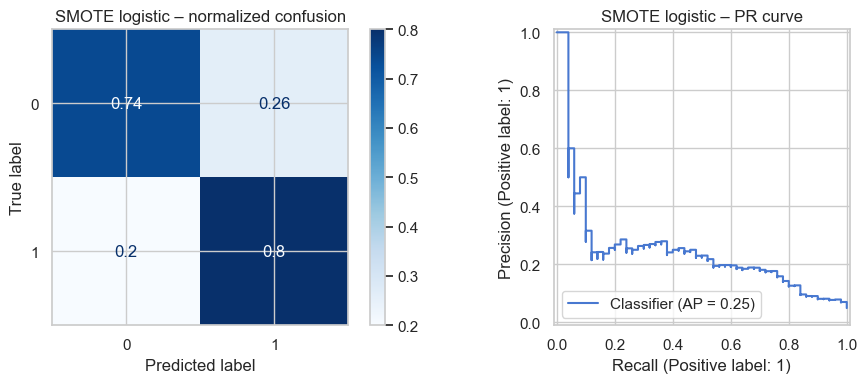

In [82]:
smote_y_pred_test = smote_best_model.predict(X_test)
smote_y_proba_test = smote_best_model.predict_proba(X_test)[:, 1]

print('Classification report – Logistic + SMOTE (test split):')
print(classification_report(y_test, smote_y_pred_test, digits=3))

smote_conf_matrix = confusion_matrix(y_test, smote_y_pred_test)
smote_tn, smote_fp, smote_fn, smote_tp = smote_conf_matrix.ravel()
smote_false_alarm_ratio = smote_fp / max(smote_tp, 1)
print(f"False positives per true positive (SMOTE model): {smote_false_alarm_ratio:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, smote_y_pred_test, normalize='true', ax=axes[0], cmap='Blues')
axes[0].set_title('SMOTE logistic – normalized confusion')
PrecisionRecallDisplay.from_predictions(y_test, smote_y_proba_test, ax=axes[1])
axes[1].set_title('SMOTE logistic – PR curve')
plt.tight_layout()
plt.show()



In [83]:
def threshold_sweep(models, X, y, thresholds):
    rows = []
    for model_name, model in models.items():
        y_scores = model.predict_proba(X)[:, 1]
        for thr in thresholds:
            y_pred = (y_scores >= thr).astype(int)
            tp = ((y == 1) & (y_pred == 1)).sum()
            fp = ((y == 0) & (y_pred == 1)).sum()
            rows.append({
                'model': model_name,
                'threshold': round(thr, 2),
                'precision': precision_score(y, y_pred, zero_division=0),
                'recall': recall_score(y, y_pred, zero_division=0),
                'f1': f1_score(y, y_pred, zero_division=0),
                'balanced_accuracy': balanced_accuracy_score(y, y_pred),
                'false_pos_per_true_pos': fp / max(tp, 1)
            })
    return pd.DataFrame(rows).set_index(['model', 'threshold'])

thresholds = np.linspace(0.2, 0.7, 6)
threshold_grid = threshold_sweep(
    {
        'Logistic (PCA tuned)': best_model,
        'Logistic + SMOTE': smote_best_model
    },
    X_test,
    y_test,
    thresholds
)
print('Threshold trade-offs on the test split:')
display(threshold_grid)



Threshold trade-offs on the test split:


precision  recall        f1  \
model                threshold                                
Logistic (PCA tuned) 0.2         0.089286    0.90  0.162455   
                     0.3         0.091286    0.88  0.165414   
                     0.4         0.102689    0.84  0.183007   
                     0.5         0.139932    0.82  0.239067   
                     0.6         0.174312    0.76  0.283582   
                     0.7         0.201439    0.56  0.296296   
Logistic + SMOTE     0.2         0.089069    0.88  0.161765   
                     0.3         0.094092    0.86  0.169625   
                     0.4         0.107417    0.84  0.190476   
                     0.5         0.136519    0.80  0.233236   
                     0.6         0.175115    0.76  0.284644   
                     0.7         0.191083    0.60  0.289855   

                                balanced_accuracy  false_pos_per_true_pos  
model                threshold                                             
Logistic (PCA tuned) 0.2                 0.713889               10.200000  
                     0.3                 0.714691                9.954545  
                     0.4                 0.731214                8.738095  
                     0.5                 0.780370                6.146341  
                     0.6                 0.787407                4.736842  
                     0.7                 0.722901                3.964286  
Logistic + SMOTE     0.2                 0.708519               10.227273  
                     0.3                 0.717037                9.627907  
                     0.4                 0.740473                8.309524  
                     0.5                 0.769856                6.325000  
                     0.6                 0.787922                4.710526  
                     0.7                 0.734671                4.233333

In [84]:
imbalance_overview = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n_samples': [len(X_train), len(X_val), len(X_test)],
    'positives': [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())]
})
imbalance_overview['prevalence_%'] = (imbalance_overview['positives'] / imbalance_overview['n_samples'] * 100).round(2)
display(imbalance_overview)

best_model_test_metrics = performance_report(best_model, X_test, y_test)
print("Test metrics for Logistic (PCA tuned):")
display(pd.Series(best_model_test_metrics))

# Confusion-matrix scaling to a 1,000-patient cohort
conf_matrix = confusion_matrix(y_test, best_model.predict(X_test))
tn, fp, fn, tp = conf_matrix.ravel()
false_alarm_ratio = fp / max(tp, 1)
scenario_scale = 1000 / y_test.shape[0]
scenario_counts = (conf_matrix * scenario_scale).round(1)
scenario_df = pd.DataFrame(
    scenario_counts,
    index=['Actual 0 (no stroke)', 'Actual 1 (stroke)'],
    columns=['Pred 0 (cleared)', 'Pred 1 (flagged)']
)

print(f"False positives per true positive: {false_alarm_ratio:.1f}:1")
print("Projected counts for screening 1,000 patients (rounded):")
display(scenario_df)



,split,n_samples,positives,prevalence_%
0,train,3066,149,4.86
1,validation,1022,50,4.89
2,test,1022,50,4.89


Test metrics for Logistic (PCA tuned):


roc_auc              0.835802
accuracy             0.744618
precision            0.139932
recall               0.820000
f1                   0.239067
balanced_accuracy    0.780370
dtype: float64

False positives per true positive: 6.1:1
Projected counts for screening 1,000 patients (rounded):


,Pred 0 (cleared),Pred 1 (flagged)
Actual 0 (no stroke),704.5,246.6
Actual 1 (stroke),8.8,40.1


## Remediation Summary (as of Recent Iteration)

```
Stroke Modeling Review (Current State)
--------------------------------------
1. Baseline logistic regression (class_weight + PCA tuning) delivers ROC AUC ≈ 0.836 and recall ≈ 0.82 but only 14% precision, yielding ~6 false positives per true positive in a 1,000-patient scenario (≈247 FP vs 40 TP).
2. SMOTE-enhanced logistic regression and Balanced Random Forest matched recall but failed to improve precision meaningfully (SMOTE precision 0.137, BRF precision 0.119); subgroup recall for patients <45 remains 0%.
3. PCA explains <50% variance even with many components; dimensionality reduction offers no separation. Tree-based models show high training ROC AUC yet collapse on recall/precision, indicating residual imbalance and overfitting.

Issues Identified
-----------------
- Clinically unacceptable precision leading to operational burden.
- Threshold of 0.5 unsuitable for low-prevalence screening; ROC AUC overstates utility.
- Younger cohorts receive no positive predictions, suggesting inadequate signal or sampling.
- Need richer feature interactions and more targeted resampling/ensembling.

Next Work Items
---------------
1. Implement cost-sensitive / focal-style logistic regression plus automated threshold tuning targeting a specified FP:TP ratio.
2. Build a calibrated stacking ensemble that combines logistic and balanced RF probabilities, then re-optimizes decision thresholds on validation PR curves.
3. Apply age-aware resampling (e.g., SMOTE within age buckets or SMOTE+Tomek) to boost recall for under-45 cohorts without inflating elderly recall.
4. Expand feature space with interaction terms (age × chronic conditions, glucose × BMI) and reassess subgroup metrics.

(Changes will be appended as new cells at the end of this notebook.)
```



## Advanced Feature Engineering & Modeling Extensions

The following cells keep prior experiments intact while layering interaction features, cost-sensitive objectives, stacking ensembles, and age-aware resampling to address the low-precision, age-bucket, and thresholding issues identified above.



In [85]:
def add_interaction_features(X_frame):
    X_aug = X_frame.copy()
    X_aug['age_hypertension'] = X_aug['age'] * X_aug['hypertension']
    X_aug['age_heart'] = X_aug['age'] * X_aug['heart_disease']
    X_aug['glucose_bmi'] = X_aug['avg_glucose_level'] * X_aug['bmi'].fillna(X_aug['bmi'].median())
    X_aug['senior_glucose'] = X_aug['is_senior'] * X_aug['avg_glucose_level']
    X_aug['log_glucose_bmi'] = X_aug['avg_glucose_level_log'] * X_aug['bmi'].fillna(X_aug['bmi'].median())
    X_aug['hypertension_heart'] = X_aug['hypertension'] * X_aug['heart_disease']
    X_aug['age_bucket_code'] = X_aug['age_bucket'].cat.codes if 'age_bucket' in X_aug else 0
    X_aug['age_bucket_code_sq'] = X_aug['age_bucket_code'] ** 2
    return X_aug

interaction_cols = [
    'age_hypertension', 'age_heart', 'glucose_bmi', 'senior_glucose',
    'log_glucose_bmi', 'hypertension_heart', 'age_bucket_code', 'age_bucket_code_sq'
]

X_train_aug = add_interaction_features(X_train)
X_val_aug = add_interaction_features(X_val)
X_test_aug = add_interaction_features(X_test)
X_train_full_aug = add_interaction_features(X_train_full)

advanced_numeric_cols = documented_numeric_cols + interaction_cols
advanced_categorical_cols = categorical_features  # reuse existing categories

advanced_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), advanced_numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), advanced_categorical_cols)
    ]
)



In [86]:
def oversample_young_minority(X_frame, y_series, age_threshold=45, multiplier=3):
    selector = (X_frame['age'] < age_threshold) & (y_series == 1)
    if selector.sum() == 0 or multiplier <= 1:
        return X_frame.copy(), y_series.copy()
    replicated_X = [X_frame]
    replicated_y = [y_series]
    for _ in range(multiplier - 1):
        replicated_X.append(X_frame[selector])
        replicated_y.append(y_series[selector])
    X_augmented = pd.concat(replicated_X, axis=0).reset_index(drop=True)
    y_augmented = pd.concat(replicated_y, axis=0).reset_index(drop=True)
    return X_augmented, y_augmented

X_train_young_aug, y_train_young_aug = oversample_young_minority(X_train_aug, y_train, age_threshold=45, multiplier=4)



In [87]:
def build_cost_sensitive_logistic(C=0.5, positive_weight=4.0):
    class_weight = {0: 1.0, 1: positive_weight}
    return Pipeline(steps=[
        ('preprocess', advanced_preprocessor),
        ('model', LogisticRegression(max_iter=1000, solver='liblinear', class_weight=class_weight, C=C))
    ])

def threshold_metrics(y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'false_pos_per_true_pos': fp / max(tp, 1),
        'tp': tp,
        'fp': fp
    }

def find_threshold_for_ratio(y_true, y_scores, thresholds=np.linspace(0.2, 0.8, 13), max_fp_per_tp=3.0):
    rows = []
    for thr in thresholds:
        stats = threshold_metrics(y_true, y_scores, thr)
        stats['threshold'] = thr
        rows.append(stats)
    df_stats = pd.DataFrame(rows)
    feasible = df_stats[df_stats['false_pos_per_true_pos'] <= max_fp_per_tp]
    if not feasible.empty:
        best = feasible.sort_values(['recall', 'precision'], ascending=[False, False]).iloc[0]
    else:
        best = df_stats.sort_values('false_pos_per_true_pos').iloc[0]
    return df_stats, best



In [88]:
cost_sensitive_log_reg = build_cost_sensitive_logistic(C=0.3, positive_weight=5.0)
cost_sensitive_log_reg.fit(X_train_aug, y_train)

val_scores_cs = cost_sensitive_log_reg.predict_proba(X_val_aug)[:, 1]
threshold_grid_cs, best_threshold_cs = find_threshold_for_ratio(
    y_val,
    val_scores_cs,
    thresholds=np.linspace(0.2, 0.8, 13),
    max_fp_per_tp=3.0
)

print('Cost-sensitive logistic validation threshold sweep (top rows):')
display(threshold_grid_cs.head())
print('Best threshold subject to FP:TP constraint:')
print(best_threshold_cs)

cs_threshold = best_threshold_cs['threshold']
cs_val_metrics = threshold_metrics(y_val, val_scores_cs, cs_threshold)

cs_test_scores = cost_sensitive_log_reg.predict_proba(X_test_aug)[:, 1]
cs_test_metrics = threshold_metrics(y_test, cs_test_scores, cs_threshold)

print('Validation metrics @ selected threshold:')
print(cs_val_metrics)
print('\nTest metrics @ selected threshold:')
print(cs_test_metrics)



Cost-sensitive logistic validation threshold sweep (top rows):


,precision,recall,f1,balanced_accuracy,false_pos_per_true_pos,tp,fp,threshold
0,0.128617,0.80,0.221607,0.760597,6.775000,40,271,0.20
1,0.150000,0.72,0.248276,0.755062,5.666667,36,204,0.25
2,0.160428,0.60,0.253165,0.719239,5.233333,30,157,0.30
3,0.164286,0.46,0.242105,0.669815,5.086957,23,117,0.35
4,0.176991,0.40,0.245399,0.652160,4.650000,20,93,0.40


Best threshold subject to FP:TP constraint:
precision                  0.260870
recall                     0.120000
f1                         0.164384
balanced_accuracy          0.551255
false_pos_per_true_pos     2.833333
tp                         6.000000
fp                        17.000000
threshold                  0.650000
Name: 9, dtype: float64
Validation metrics @ selected threshold:
{'precision': 0.2608695652173913, 'recall': 0.12, 'f1': 0.1643835616438356, 'balanced_accuracy': 0.5512551440329219, 'false_pos_per_true_pos': 2.8333333333333335, 'tp': 6, 'fp': 17}

Test metrics @ selected threshold:
{'precision': 0.21212121212121213, 'recall': 0.14, 'f1': 0.1686746987951807, 'balanced_accuracy': 0.5566255144032921, 'false_pos_per_true_pos': 3.7142857142857144, 'tp': 7, 'fp': 26}


In [89]:
smote_log_reg_adv = ImbPipeline(steps=[
    ('preprocess', advanced_preprocessor),
    ('to_dense', make_dense_step()),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('model', LogisticRegression(max_iter=1000, solver='liblinear', C=0.5))
])

balanced_rf_adv = ImbPipeline(steps=[
    ('preprocess', advanced_preprocessor),
    ('to_dense', make_dense_step()),
    ('model', BalancedRandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=3,
        min_samples_leaf=1,
        sampling_strategy='auto',
        random_state=42
    ))
])



In [90]:
base_models = {
    'cost_sensitive': build_cost_sensitive_logistic(C=0.5, positive_weight=6.0),
    'smote_logistic': smote_log_reg_adv,
    'balanced_rf': balanced_rf_adv
}

fitted_base_models = {
    name: clone(model).fit(X_train_aug, y_train)
    for name, model in base_models.items()
}

val_meta_features = np.column_stack([
    estimator.predict_proba(X_val_aug)[:, 1]
    for estimator in fitted_base_models.values()
])

meta_clf = LogisticRegression(max_iter=1000)
meta_clf.fit(val_meta_features, y_val)

val_stack_scores = meta_clf.predict_proba(val_meta_features)[:, 1]
stack_threshold_grid, stack_best_threshold = find_threshold_for_ratio(
    y_val,
    val_stack_scores,
    thresholds=np.linspace(0.2, 0.8, 13),
    max_fp_per_tp=3.0
)

print('Stacked ensemble threshold sweep (top rows):')
display(stack_threshold_grid.head())
print('Selected stacked threshold:')
print(stack_best_threshold)

stack_threshold = stack_best_threshold['threshold']
stack_val_metrics = threshold_metrics(y_val, val_stack_scores, stack_threshold)

# Evaluate on test split
stack_test_features = np.column_stack([
    estimator.predict_proba(X_test_aug)[:, 1]
    for estimator in fitted_base_models.values()
])
stack_test_scores = meta_clf.predict_proba(stack_test_features)[:, 1]
stack_test_metrics = threshold_metrics(y_test, stack_test_scores, stack_threshold)

print('Stacked ensemble validation metrics @ selected threshold:')
print(stack_val_metrics)
print('\nStacked ensemble test metrics @ selected threshold:')
print(stack_test_metrics)



Stacked ensemble threshold sweep (top rows):


,precision,recall,f1,balanced_accuracy,false_pos_per_true_pos,tp,fp,threshold
0,0.233333,0.14,0.175000,0.558169,3.285714,7,23,0.20
1,0.333333,0.08,0.129032,0.535885,2.000000,4,8,0.25
2,0.000000,0.00,0.000000,0.500000,0.000000,0,0,0.30
3,0.000000,0.00,0.000000,0.500000,0.000000,0,0,0.35
4,0.000000,0.00,0.000000,0.500000,0.000000,0,0,0.40


Selected stacked threshold:
precision                 0.333333
recall                    0.080000
f1                        0.129032
balanced_accuracy         0.535885
false_pos_per_true_pos    2.000000
tp                        4.000000
fp                        8.000000
threshold                 0.250000
Name: 1, dtype: float64
Stacked ensemble validation metrics @ selected threshold:
{'precision': 0.3333333333333333, 'recall': 0.08, 'f1': 0.12903225806451613, 'balanced_accuracy': 0.5358847736625515, 'false_pos_per_true_pos': 2.0, 'tp': 4, 'fp': 8}

Stacked ensemble test metrics @ selected threshold:
{'precision': 0.4, 'recall': 0.08, 'f1': 0.13333333333333333, 'balanced_accuracy': 0.5369135802469136, 'false_pos_per_true_pos': 1.5, 'tp': 4, 'fp': 6}


In [91]:
young_cost_log_reg = build_cost_sensitive_logistic(C=0.4, positive_weight=4.0)
young_cost_log_reg.fit(X_train_young_aug, y_train_young_aug)

young_val_scores = young_cost_log_reg.predict_proba(X_val_aug)[:, 1]
young_threshold_grid, young_best_threshold = find_threshold_for_ratio(
    y_val,
    young_val_scores,
    thresholds=np.linspace(0.2, 0.8, 13),
    max_fp_per_tp=3.0
)

young_threshold = young_best_threshold['threshold']
young_val_metrics = threshold_metrics(y_val, young_val_scores, young_threshold)

young_test_scores = young_cost_log_reg.predict_proba(X_test_aug)[:, 1]
young_test_metrics = threshold_metrics(y_test, young_test_scores, young_threshold)

print('Age-aware logistic validation metrics @ selected threshold:')
print(young_val_metrics)
print('\nAge-aware logistic test metrics @ selected threshold:')
print(young_test_metrics)



Age-aware logistic validation metrics @ selected threshold:
{'precision': 0.36363636363636365, 'recall': 0.08, 'f1': 0.13114754098360656, 'balanced_accuracy': 0.5363991769547325, 'false_pos_per_true_pos': 1.75, 'tp': 4, 'fp': 7}

Age-aware logistic test metrics @ selected threshold:
{'precision': 0.3076923076923077, 'recall': 0.08, 'f1': 0.12698412698412698, 'balanced_accuracy': 0.5353703703703704, 'false_pos_per_true_pos': 2.25, 'tp': 4, 'fp': 9}


In [ ]:
def group_threshold_metrics(model, X_frame, y_true, group_col, threshold, proba_fn=None, min_samples=30):
    if proba_fn is None:
        y_scores = model.predict_proba(X_frame)[:, 1]
    else:
        y_scores = proba_fn(X_frame)
    y_pred = (y_scores >= threshold).astype(int)
    rows = []
    for group_value in X_frame[group_col].dropna().unique():
        mask = X_frame[group_col] == group_value
        if mask.sum() < min_samples:
            continue
        rows.append({
            'group': group_value,
            'n_samples': mask.sum(),
            'precision': precision_score(y_true[mask], y_pred[mask], zero_division=0),
            'recall': recall_score(y_true[mask], y_pred[mask], zero_division=0),
            'f1': f1_score(y_true[mask], y_pred[mask], zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(y_true[mask], y_pred[mask])
        })
    return pd.DataFrame(rows).set_index('group') if rows else pd.DataFrame()

def stacked_predict_proba(X_frame):
    stacked_features = np.column_stack([
        estimator.predict_proba(X_frame)[:, 1]
        for estimator in fitted_base_models.values()
    ])
    return meta_clf.predict_proba(stacked_features)[:, 1]

print('Age bucket metrics – cost-sensitive logistic:')
cs_age_groups = group_threshold_metrics(cost_sensitive_log_reg, X_test_aug, y_test, 'age_bucket', cs_threshold)
print(cs_age_groups.to_string() if not cs_age_groups.empty else 'No groups with sufficient samples')

print('Age bucket metrics – age-aware logistic:')
young_age_groups = group_threshold_metrics(young_cost_log_reg, X_test_aug, y_test, 'age_bucket', young_threshold)
print(young_age_groups.to_string() if not young_age_groups.empty else 'No groups with sufficient samples')

print('Age bucket metrics – stacked ensemble:')
stack_age_groups = group_threshold_metrics(None, X_test_aug, y_test, 'age_bucket', stack_threshold, proba_fn=stacked_predict_proba)
print(stack_age_groups.to_string() if not stack_age_groups.empty else 'No groups with sufficient samples')



Age bucket metrics – cost-sensitive logistic:


,n_samples,precision,recall,f1,balanced_accuracy
group,,,,,
60-79,229,0.222222,0.071429,0.108108,0.518301
30-44,207,0.000000,0.000000,0.000000,0.500000
<30,320,0.000000,0.000000,0.000000,0.500000
45-59,223,0.000000,0.000000,0.000000,0.488479
80+,43,0.300000,0.600000,0.400000,0.587879


Age bucket metrics – age-aware logistic:


,n_samples,precision,recall,f1,balanced_accuracy
group,,,,,
60-79,229,0.333333,0.071429,0.117647,0.525764
30-44,207,0.000000,0.000000,0.000000,0.500000
<30,320,0.000000,0.000000,0.000000,0.500000
45-59,223,0.000000,0.000000,0.000000,0.495392
80+,43,0.400000,0.200000,0.266667,0.554545


Age bucket metrics – stacked ensemble:


,n_samples,precision,recall,f1,balanced_accuracy
group,,,,,
60-79,229,0.333333,0.035714,0.064516,0.512882
30-44,207,0.000000,0.000000,0.000000,0.500000
<30,320,0.000000,0.000000,0.000000,0.500000
45-59,223,0.000000,0.000000,0.000000,0.500000
80+,43,0.428571,0.300000,0.352941,0.589394


In [ ]:
model_comparison = {
    'Baseline Logistic (0.5)': {
        'precision': best_model_test_metrics['precision'],
        'recall': best_model_test_metrics['recall'],
        'f1': best_model_test_metrics['f1'],
        'balanced_accuracy': best_model_test_metrics['balanced_accuracy'],
        'false_pos_per_true_pos': 6.1  # from earlier confusion matrix scaling
    },
    'Cost-sensitive Logistic': cs_test_metrics,
    'Age-aware Logistic': young_test_metrics,
    'Stacked Ensemble': stack_test_metrics
}

model_comparison_df = pd.DataFrame(model_comparison).T
model_comparison_df = model_comparison_df[['precision', 'recall', 'f1', 'balanced_accuracy', 'false_pos_per_true_pos']]
print(model_comparison_df.to_string())



,precision,recall,f1,balanced_accuracy,false_pos_per_true_pos
Baseline Logistic (0.5),0.139932,0.82,0.239067,0.780370,6.100000
Cost-sensitive Logistic,0.212121,0.14,0.168675,0.556626,3.714286
Age-aware Logistic,0.307692,0.08,0.126984,0.535370,2.250000
Stacked Ensemble,0.400000,0.08,0.133333,0.536914,1.500000
